<a href="https://colab.research.google.com/github/hariharan2302/hariharan2302/blob/main/Assignment_1_checkpoint.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Assignment 1- Defining & Solving RL Environments:**




In [90]:
!pip install gymnasium matplotlib numpy


### **TASK 1**
**1.1.DETERMINISTIC ENVIRONMENT**

In [91]:
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
import numpy as np
import time

<ipython-input-92-7b7729b96fec>:23: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axes.scatter(reward_pos_3[1],reward_pos_3[0], marker='x', edgecolors='k', linewidths=3,
<ipython-input-92-7b7729b96fec>:25: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axes.scatter(reward_pos_4[1], reward_pos_4[0], marker='x', edgecolors='k', linewidths=3,


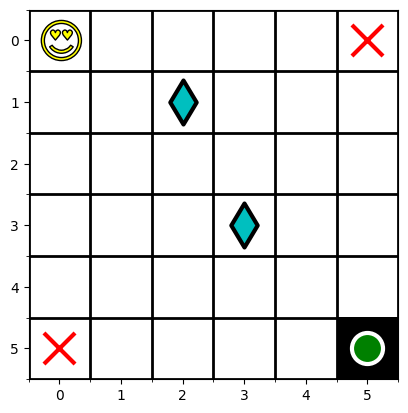

In [92]:
# Prototype of My Environment
my_grid_width = 6
my_grid_height = 6
grid = np.zeros((my_grid_height, my_grid_width))
start_pos = [0, 0]
reward_pos_1 = [3,3]
reward_pos_2 = [1,2]
reward_pos_3 = [5,0]
reward_pos_4 = [0,5]
end_pos = [5, 5]
grid[tuple(start_pos)] = 0
grid[tuple(end_pos)] = 1
figure, axes = plt.subplots()
axes.set_xticks(np.arange(-0.5, my_grid_width, 1), minor=True)
axes.set_yticks(np.arange(-0.5, my_grid_height, 1), minor=True)
axes.grid(which='minor', color='black', linestyle='-', linewidth=2)
axes.imshow(grid, cmap='binary', interpolation='nearest')
axes.scatter(end_pos[1],end_pos[0], marker='o',edgecolors='white',linewidths=3, color='g', s=500, alpha=1)
axes.scatter(reward_pos_1[1], reward_pos_1[0], marker='d', edgecolors='k', linewidths=3,
                   color='c', s=500, alpha=1)
axes.scatter(reward_pos_2[1], reward_pos_2[0], marker='d', edgecolors='k', linewidths=3,
                   color='c', s=500, alpha=1)
axes.scatter(reward_pos_3[1],reward_pos_3[0], marker='x', edgecolors='k', linewidths=3,
                   color='r', s=500, alpha=1)
axes.scatter(reward_pos_4[1], reward_pos_4[0], marker='x', edgecolors='k', linewidths=3,
                   color='r', s=500, alpha=1)
axes.scatter(start_pos[1], start_pos[0], marker='$\U0001F60D$',edgecolors='k',linewidths=1, color='yellow', s=1000, alpha=1)
plt.show()

In [93]:
class Deterministic_Environment(gym.Env):
    metadata = { 'render.modes': [] }
    def __init__(self):
      self.observation_space = spaces.Discrete(36)
      self.action_space = spaces.Discrete(4)
      self.max_timesteps = 15
      self.timestep = 0
      self.agent_pos = [0, 0]
      self.reward_pos_1 = [3,3]
      self.reward_pos_2 = [1,2]
      self.reward_pos_3 = [5,0]
      self.reward_pos_4 = [0,5]
      self.goal_pos = [5, 5]
      self.state = np.zeros((6,6))
      self.state[tuple(self.agent_pos)] = 111
      self.state[tuple(self.goal_pos)] = 888

    def reset(self, **kwargs):
      self.agent_pos = [0, 0]
      self.reward_pos_1 = [3,3]
      self.reward_pos_2 = [1,2]
      self.reward_pos_3 = [5,0]
      self.reward_pos_4 = [0,5]
      self.goal_pos = [5, 5]
      self.state = np.zeros((6,6))
      self.state[tuple(self.agent_pos)] = 111
      self.state[tuple(self.goal_pos)] = 888
      observation = self.state.flatten()
      info = {}
      return observation, info

    def step(self, action):
      if action == 0: #Down
        self.agent_pos[0] += 1
      elif action == 1: #Up
        self.agent_pos[0] -= 1
      elif action == 2: #Right
        self.agent_pos[1] += 1
      elif action == 3: #Left
        self.agent_pos[1] -= 1
      self.agent_pos = np.clip(self.agent_pos, 0, 5)
      self.state = np.zeros((6,6))
      self.state[tuple(self.agent_pos)] = 111
      self.state[tuple(self.goal_pos)] = 888
      print("Current State:", self.state)
      observation = self.state.flatten()
      reward = 0
      if np.array_equal(self.agent_pos, self.goal_pos):
        terminated = True
        reward = 1
      else:
        terminated = False
        reward = 0
      if np.array_equal(self.agent_pos, self.reward_pos_1) or np.array_equal(self.agent_pos, self.reward_pos_2):
        reward = 1
      elif np.array_equal(self.agent_pos, self.reward_pos_3) or np.array_equal(self.agent_pos, self.reward_pos_4):
        reward = -1
      self.timestep += 1
      if self.timestep >= self.max_timesteps:
            terminated = True
      truncated = True if np.all((np.asarray(self.agent_pos) >=0 ) & (np.asarray(self.agent_pos) <= 5)) else False
      return observation, reward, terminated, truncated

    def render(self,agent_actions,ax=None):
      if ax is None:
        fig, ax = plt.subplots()
      my_grid_width = 6
      my_grid_height = 6
      grid = np.zeros((my_grid_height, my_grid_width))
      grid[tuple(self.goal_pos)] = 1
      grid[tuple(self.reward_pos_1)] = 0.5
      grid[tuple(self.reward_pos_2)] = 0.5
      grid[tuple(self.reward_pos_3)] = -0.5
      grid[tuple(self.reward_pos_4)] = -0.5
      for a_position in agent_actions:
        grid[tuple(a_position)] = 0
      ax.set_xticks(np.arange(-0.5, my_grid_width, 1), minor=True)
      ax.set_yticks(np.arange(-0.5, my_grid_height, 1), minor=True)
      ax.grid(which='minor', color='black', linestyle='-', linewidth=2)
      ax.imshow(grid, cmap='binary', interpolation='nearest')
      ax.scatter(self.goal_pos[1], self.goal_pos[0], marker='o',edgecolors='white',linewidths=3, color='g', s=500, alpha=1)
      ax.scatter(self.reward_pos_1[1], self.reward_pos_1[0], marker='d', edgecolors='k', linewidths=3,
                   color='c', s=500, alpha=1)
      ax.scatter(self.reward_pos_2[1], self.reward_pos_2[0], marker='d', edgecolors='k', linewidths=3,
                   color='c', s=500, alpha=1)
      ax.scatter(self.reward_pos_3[1], self.reward_pos_3[0], marker='X', edgecolors='k', linewidths=3,
                   color='r', s=500, alpha=1)
      ax.scatter(self.reward_pos_4[1], self.reward_pos_4[0], marker='X', edgecolors='k', linewidths=3,
                   color='r', s=500, alpha=1)
      ax.scatter(agent_actions[-1][1], agent_actions[-1][0], marker='$\U0001F60D$',edgecolors='k',linewidths=1, color='yellow', s=1000, alpha=1)
      plt.show()


Current State: [[  0.   0.   0.   0.   0.   0.]
 [111.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 888.]]
Chosen Action: 0
Reward Gained: 0
Game Over: False
Agent is within the Grid: True


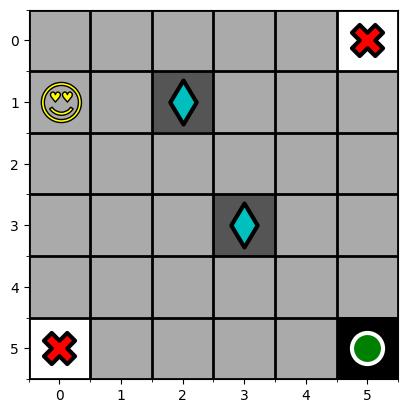

Current State: [[  0.   0.   0.   0.   0.   0.]
 [  0. 111.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 888.]]
Chosen Action: 2
Reward Gained: 0
Game Over: False
Agent is within the Grid: True


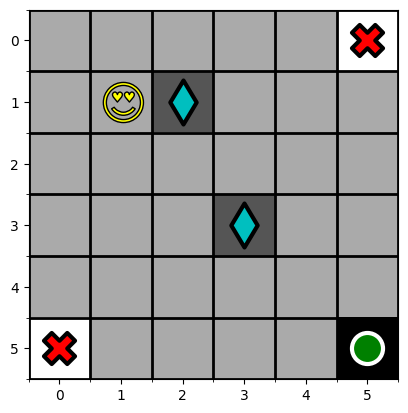

Current State: [[  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0. 111.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 888.]]
Chosen Action: 0
Reward Gained: 0
Game Over: False
Agent is within the Grid: True


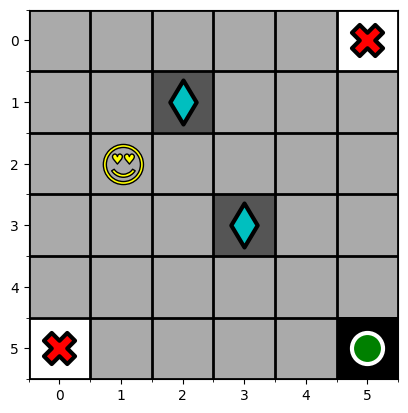

Current State: [[  0.   0.   0.   0.   0.   0.]
 [  0. 111.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 888.]]
Chosen Action: 1
Reward Gained: 0
Game Over: False
Agent is within the Grid: True


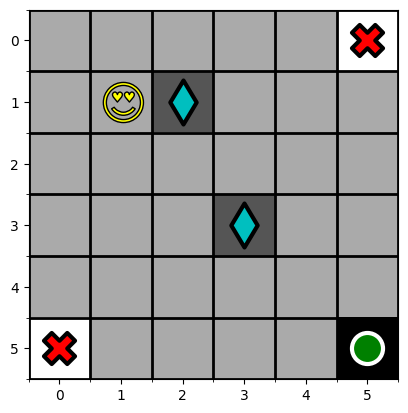

Current State: [[  0.   0.   0.   0.   0.   0.]
 [  0.   0. 111.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 888.]]
Chosen Action: 2
Reward Gained: 1
Game Over: False
Agent is within the Grid: True


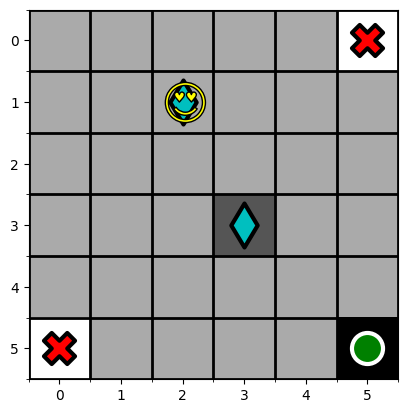

Current State: [[  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0. 111.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 888.]]
Chosen Action: 2
Reward Gained: 0
Game Over: False
Agent is within the Grid: True


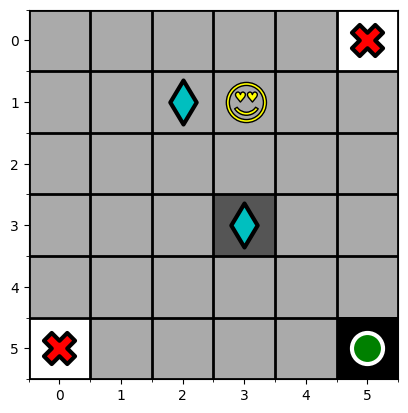

Current State: [[  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0. 111.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 888.]]
Chosen Action: 2
Reward Gained: 0
Game Over: False
Agent is within the Grid: True


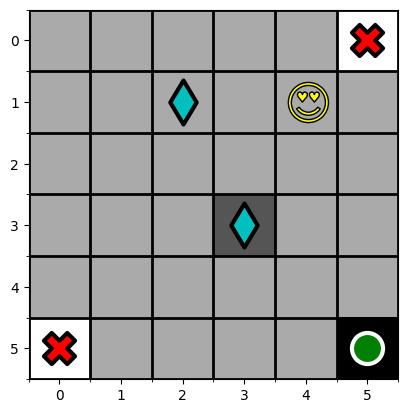

Current State: [[  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 111.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 888.]]
Chosen Action: 2
Reward Gained: 0
Game Over: False
Agent is within the Grid: True


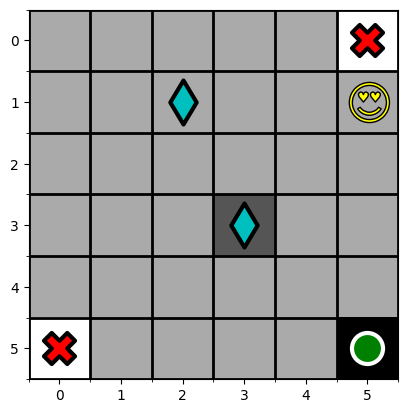

Current State: [[  0.   0.   0.   0.   0. 111.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 888.]]
Chosen Action: 1
Reward Gained: -1
Game Over: False
Agent is within the Grid: True


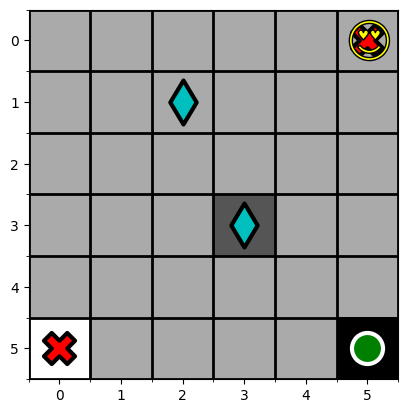

Current State: [[  0.   0.   0.   0.   0. 111.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 888.]]
Chosen Action: 1
Reward Gained: -1
Game Over: False
Agent is within the Grid: True


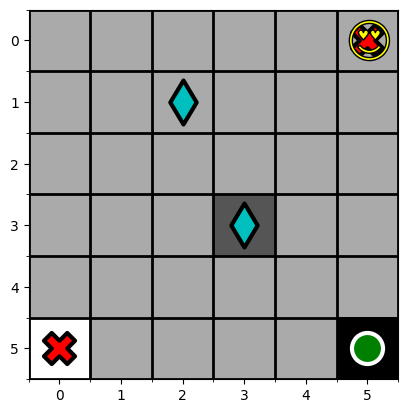

Current State: [[  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 111.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 888.]]
Chosen Action: 0
Reward Gained: 0
Game Over: False
Agent is within the Grid: True


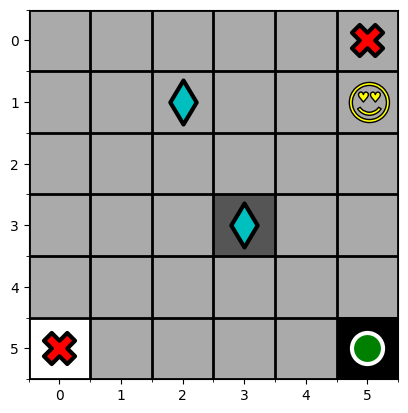

Current State: [[  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 111.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 888.]]
Chosen Action: 0
Reward Gained: 0
Game Over: False
Agent is within the Grid: True


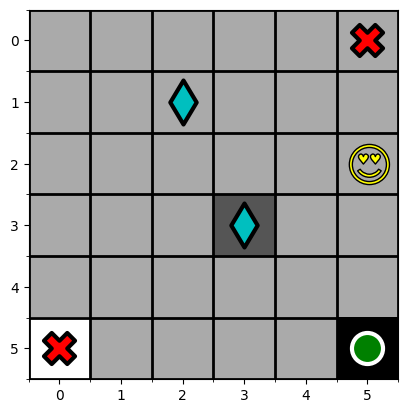

Current State: [[  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 111.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 888.]]
Chosen Action: 1
Reward Gained: 0
Game Over: False
Agent is within the Grid: True


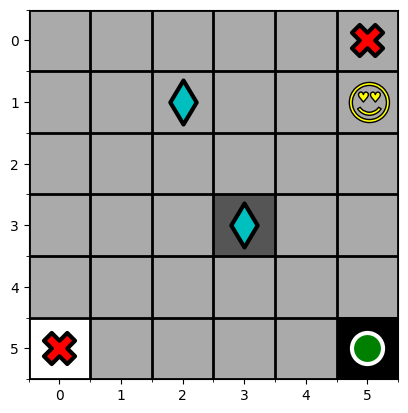

Current State: [[  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 111.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 888.]]
Chosen Action: 2
Reward Gained: 0
Game Over: False
Agent is within the Grid: True


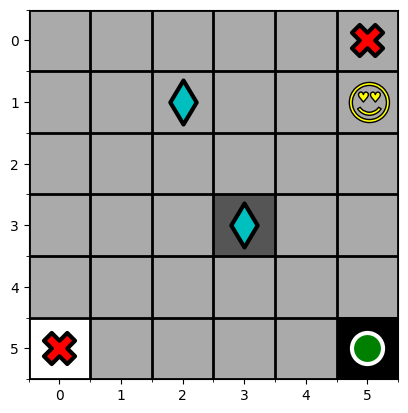

Current State: [[  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 111.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 888.]]
Chosen Action: 2
Reward Gained: 0
Game Over: True
Agent is within the Grid: True
Sorry! You have reached the maximum timesteps


In [94]:
class Random_Agent_Action:
  def __init__(self, env):
    self.env = env
    self.observation_space = env.observation_space
    self.action_space = env.action_space
  def step(self, obs):
    return np.random.choice(self.action_space.n)

my_env = Deterministic_Environment()
user_agent = Random_Agent_Action(my_env)
terminated, truncated = False, False
obs, info = my_env.reset()
agent_actions = []
while not terminated:
    a_move = user_agent.step(obs)
    observation, reward, terminated, truncated = my_env.step(a_move)
    print("Chosen Action:", a_move)
    print("Reward Gained:", reward)
    print("Game Over:", terminated)
    print("Agent is within the Grid:", truncated)
    if terminated != True:
      agent_actions.append((my_env.agent_pos[0], my_env.agent_pos[1]))
      time.sleep(0.5)
      my_env.render(agent_actions)
    else:
      print("Sorry! You have reached the maximum timesteps")
      my_env.reset()

**1.2. Stochastic Environment**

In [95]:
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
import numpy as np
import time

In [96]:
class Stochastic_Environment(gym.Env):
    metadata = { 'render.modes': [] }
    def __init__(self,stochastic_action=0.05):
      self.observation_space = spaces.Discrete(36)
      self.action_space = spaces.Discrete(4)
      self.max_timesteps = 15
      self.timestep = 0
      self.agent_pos = [0, 0]
      self.reward_pos_1 = [3,3]
      self.reward_pos_2 = [1,2]
      self.reward_pos_3 = [5,0]
      self.reward_pos_4 = [0,5]
      self.goal_pos = [5, 5]
      self.state = np.zeros((6,6))
      self.state[tuple(self.agent_pos)] = 111
      self.state[tuple(self.goal_pos)] = 888
      self.stochastic_action = stochastic_action

    def reset(self, **kwargs):
      self.agent_pos = [0, 0]
      self.reward_pos_1 = [3,3]
      self.reward_pos_2 = [1,2]
      self.reward_pos_3 = [5,0]
      self.reward_pos_4 = [0,5]
      self.goal_pos = [5, 5]
      self.state = np.zeros((6,6))
      self.state[tuple(self.agent_pos)] = 111
      self.state[tuple(self.goal_pos)] = 888
      observation = self.state.flatten()
      info = {}
      return observation, info

    def step(self, action):
      if np.random.rand() < self.stochastic_action:
        alternate_action = [act for act in range(self.action_space.n) if act != action]
        action = np.random.choice(alternate_action)
        print("Its a Stochastic Move")
        print("Alternate Action", action)
      if action == 0: #Down
        self.agent_pos[0] += 1
      elif action == 1: #Up
        self.agent_pos[0] -= 1
      elif action == 2: #Right
        self.agent_pos[1] += 1
      elif action == 3: #Left
        self.agent_pos[1] -= 1
      self.agent_pos = np.clip(self.agent_pos, 0, 5)
      self.state = np.zeros((6,6))
      self.state[tuple(self.agent_pos)] = 111
      self.state[tuple(self.goal_pos)] = 888
      print("Current State:", self.state)
      observation = self.state.flatten()
      reward = 0
      if np.array_equal(self.agent_pos, self.goal_pos):
        terminated = True
        reward = 1
      else:
        terminated = False
        reward = 0
      if np.array_equal(self.agent_pos, self.reward_pos_1) or np.array_equal(self.agent_pos, self.reward_pos_2):
        reward = 1
      elif np.array_equal(self.agent_pos, self.reward_pos_3) or np.array_equal(self.agent_pos, self.reward_pos_4):
        reward = -1
      self.timestep += 1
      if self.timestep >= self.max_timesteps:
            terminated = True
      truncated = True if np.all((np.asarray(self.agent_pos) >=0 ) & (np.asarray(self.agent_pos) <= 5)) else False
      return observation, reward, terminated, truncated

    def render(self,agent_actions,ax=None):
      if ax is None:
        fig, ax = plt.subplots()
      my_grid_width = 6
      my_grid_height = 6
      grid = np.zeros((my_grid_height, my_grid_width))
      grid[tuple(self.goal_pos)] = 1
      grid[tuple(self.reward_pos_1)] = 0.5
      grid[tuple(self.reward_pos_2)] = 0.5
      grid[tuple(self.reward_pos_3)] = -0.5
      grid[tuple(self.reward_pos_4)] = -0.5
      for a_position in agent_actions:
        grid[tuple(a_position)] = 0
      ax.set_xticks(np.arange(-0.5, my_grid_width, 1), minor=True)
      ax.set_yticks(np.arange(-0.5, my_grid_height, 1), minor=True)
      ax.grid(which='minor', color='black', linestyle='-', linewidth=2)
      ax.imshow(grid, cmap='binary', interpolation='nearest')
      ax.scatter(self.goal_pos[1], self.goal_pos[0], marker='o',edgecolors='white',linewidths=3, color='g', s=500, alpha=1)
      ax.scatter(self.reward_pos_1[1], self.reward_pos_1[0], marker='d', edgecolors='k', linewidths=3,
                   color='c', s=500, alpha=1)
      ax.scatter(self.reward_pos_2[1], self.reward_pos_2[0], marker='d', edgecolors='k', linewidths=3,
                   color='c', s=500, alpha=1)
      ax.scatter(self.reward_pos_3[1], self.reward_pos_3[0], marker='X', edgecolors='k', linewidths=3,
                   color='r', s=500, alpha=1)
      ax.scatter(self.reward_pos_4[1], self.reward_pos_4[0], marker='X', edgecolors='k', linewidths=3,
                   color='r', s=500, alpha=1)
      ax.scatter(agent_actions[-1][1], agent_actions[-1][0], marker='$\U0001F60D$',edgecolors='k',linewidths=1, color='yellow', s=1000, alpha=1)
      plt.show()


Current State: [[111.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 888.]]
Chosen Action: 1
Reward Gained: 0
Game Over: False
Agent is within the Grid: True


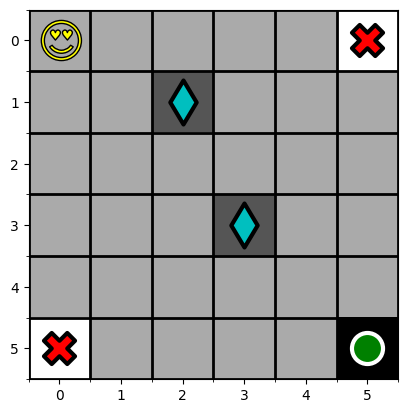

Current State: [[  0.   0.   0.   0.   0.   0.]
 [111.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 888.]]
Chosen Action: 0
Reward Gained: 0
Game Over: False
Agent is within the Grid: True


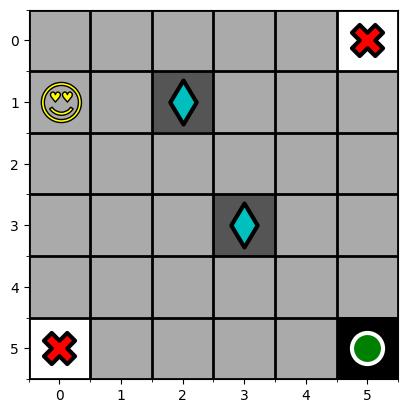

Current State: [[111.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 888.]]
Chosen Action: 1
Reward Gained: 0
Game Over: False
Agent is within the Grid: True


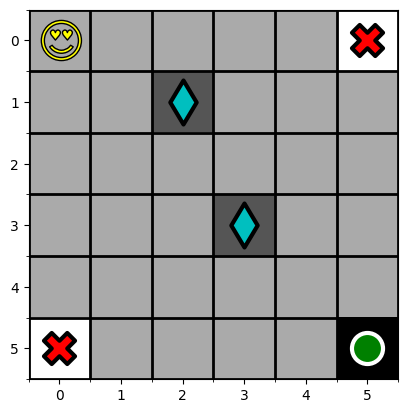

Current State: [[111.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 888.]]
Chosen Action: 1
Reward Gained: 0
Game Over: False
Agent is within the Grid: True


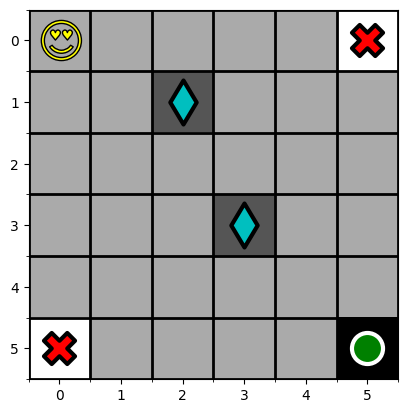

Current State: [[111.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 888.]]
Chosen Action: 3
Reward Gained: 0
Game Over: False
Agent is within the Grid: True


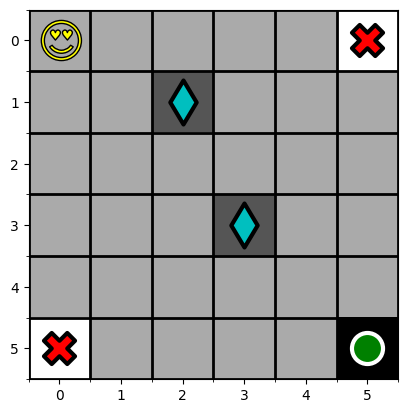

Current State: [[  0.   0.   0.   0.   0.   0.]
 [111.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 888.]]
Chosen Action: 0
Reward Gained: 0
Game Over: False
Agent is within the Grid: True


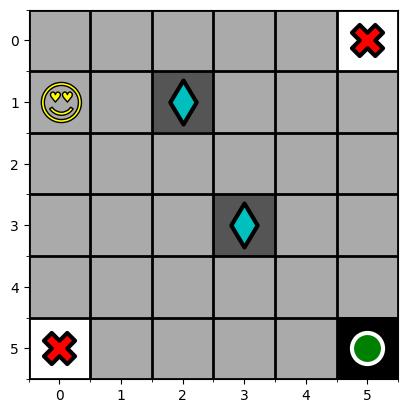

Current State: [[  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [111.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 888.]]
Chosen Action: 0
Reward Gained: 0
Game Over: False
Agent is within the Grid: True


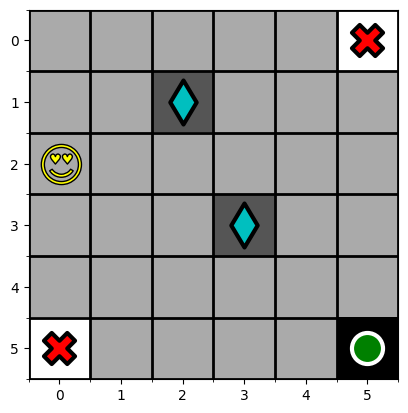

Current State: [[  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0. 111.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 888.]]
Chosen Action: 2
Reward Gained: 0
Game Over: False
Agent is within the Grid: True


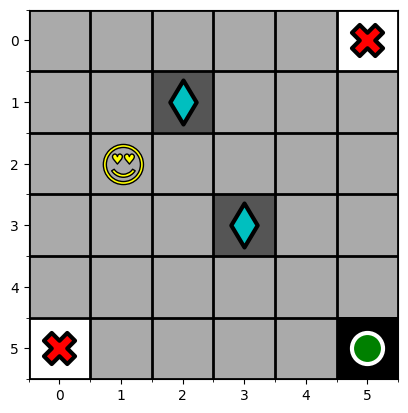

Current State: [[  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [111.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 888.]]
Chosen Action: 3
Reward Gained: 0
Game Over: False
Agent is within the Grid: True


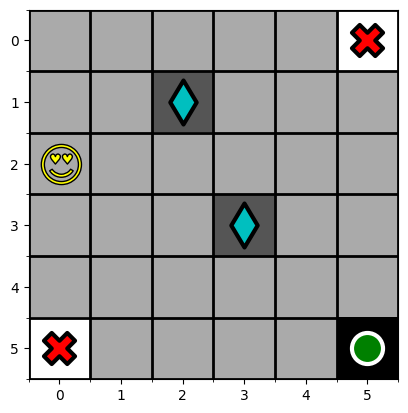

Current State: [[  0.   0.   0.   0.   0.   0.]
 [111.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 888.]]
Chosen Action: 1
Reward Gained: 0
Game Over: False
Agent is within the Grid: True


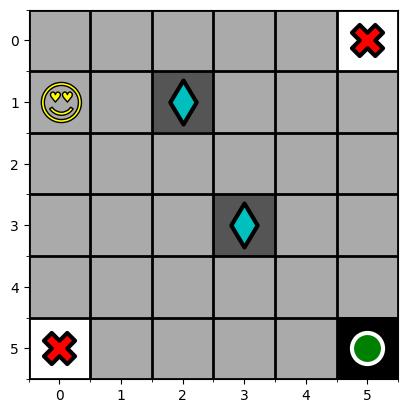

Its a Stochastic Move
Alternate Action 0
Current State: [[  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [111.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 888.]]
Chosen Action: 1
Reward Gained: 0
Game Over: False
Agent is within the Grid: True


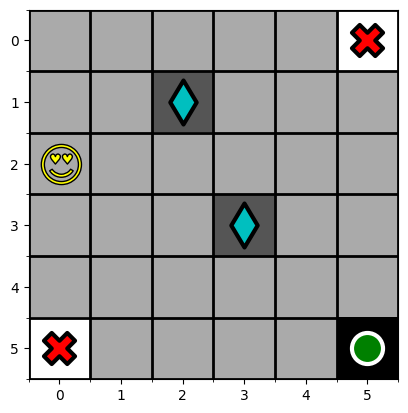

Current State: [[  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0. 111.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 888.]]
Chosen Action: 2
Reward Gained: 0
Game Over: False
Agent is within the Grid: True


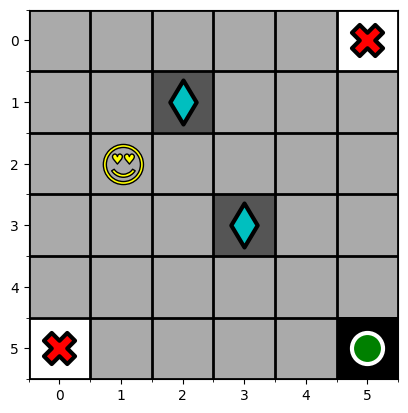

Current State: [[  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [111.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 888.]]
Chosen Action: 3
Reward Gained: 0
Game Over: False
Agent is within the Grid: True


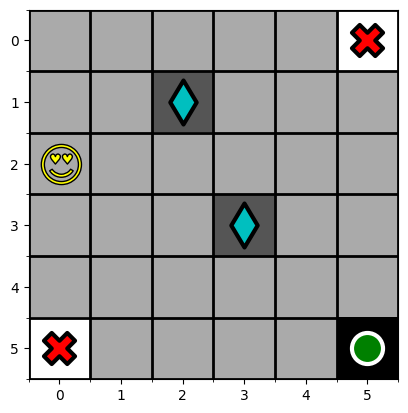

Current State: [[  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0. 111.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 888.]]
Chosen Action: 2
Reward Gained: 0
Game Over: False
Agent is within the Grid: True


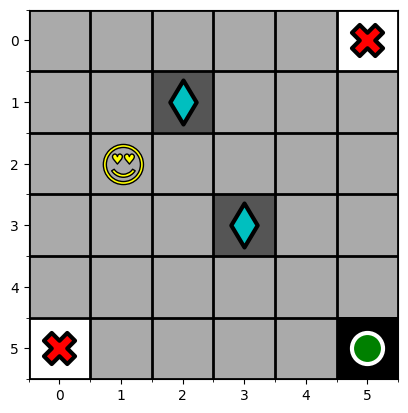

Current State: [[  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0. 111.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 888.]]
Chosen Action: 2
Reward Gained: 0
Game Over: True
Agent is within the Grid: True
Sorry! You have reached the maximum timesteps


In [97]:
class Random_Agent_Action:
  def __init__(self, env):
    self.env = env
    self.observation_space = env.observation_space
    self.action_space = env.action_space
  def step(self, obs):
    return np.random.choice(self.action_space.n)

my_env = Stochastic_Environment()
user_agent = Random_Agent_Action(my_env)
terminated, truncated = False, False
obs, info = my_env.reset()
agent_actions = []
while not terminated:
    a_move = user_agent.step(obs)
    observation, reward, terminated, truncated = my_env.step(a_move)
    print("Chosen Action:", a_move)
    print("Reward Gained:", reward)
    print("Game Over:", terminated)
    print("Agent is within the Grid:", truncated)
    if terminated != True:
      agent_actions.append((my_env.agent_pos[0], my_env.agent_pos[1]))
      time.sleep(0.5)
      my_env.render(agent_actions)
    else:
      print("Sorry! You have reached the maximum timesteps")
      my_env.reset()

### Task 2
**2.1. Q-Learning**
(For Deterministic Environment)


In [98]:
import pickle
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
import numpy as np
import time
from collections import defaultdict
import pandas as pd



In [99]:

class Deterministic_Environment(gym.Env):
    metadata = { 'render.modes': [] }
    def __init__(self):
      self.observation_space = spaces.Discrete(36)
      self.action_space = spaces.Discrete(4)
      self.max_timesteps = 15
      self.timestep = 0
      self.agent_pos = [0, 0]
      self.reward_pos_1 = [3,3]
      self.reward_pos_2 = [1,2]
      self.reward_pos_3 = [5,0]
      self.reward_pos_4 = [0,5]
      self.goal_pos = [5, 5]
      self.state = np.zeros((6,6))
      self.state[tuple(self.agent_pos)] = 111
      self.state[tuple(self.goal_pos)] = 888

    def reset(self, **kwargs):
      self.agent_pos = [0, 0]
      self.reward_pos_1 = [3,3]
      self.reward_pos_2 = [1,2]
      self.reward_pos_3 = [5,0]
      self.reward_pos_4 = [0,5]
      self.goal_pos = [5, 5]
      self.timestep = 0
      self.state = np.zeros((6,6))
      self.state[tuple(self.agent_pos)] = 111
      self.state[tuple(self.goal_pos)] = 888
      observation = self.state.flatten()
      return observation

    def step(self, action):
      if action == 0: #Down
        self.agent_pos[0] += 1
      elif action == 1: #Up
        self.agent_pos[0] -= 1
      elif action == 2: #Right
        self.agent_pos[1] += 1
      elif action == 3: #Left
        self.agent_pos[1] -= 1
      self.agent_pos = np.clip(self.agent_pos, 0, 5)
      self.state = np.zeros((6,6))
      self.state[tuple(self.agent_pos)] = 111
      self.state[tuple(self.goal_pos)] = 888
      print("Current State:", self.state)
      observation = self.state.flatten()
      reward = 0
      if np.array_equal(self.agent_pos, self.goal_pos):
        terminated = True
        reward = 1
      else:
        terminated = False
        reward = 0
      if np.array_equal(self.agent_pos, self.reward_pos_1) or np.array_equal(self.agent_pos, self.reward_pos_2):
        reward = 1
      elif np.array_equal(self.agent_pos, self.reward_pos_3) or np.array_equal(self.agent_pos, self.reward_pos_4):
        reward = -1
      self.timestep += 1
      if self.timestep >= self.max_timesteps:
            terminated = True
      truncated = True if np.all((np.asarray(self.agent_pos) >=0 ) & (np.asarray(self.agent_pos) <= 5)) else False
      return observation, reward, terminated, truncated

    def render(self,agent_actions,ax=None):
      if ax is None:
        fig, ax = plt.subplots()
      my_grid_width = 6
      my_grid_height = 6
      grid = np.zeros((my_grid_height, my_grid_width))
      grid[tuple(self.goal_pos)] = 1
      grid[tuple(self.reward_pos_1)] = 0.5
      grid[tuple(self.reward_pos_2)] = 0.5
      grid[tuple(self.reward_pos_3)] = -0.5
      grid[tuple(self.reward_pos_4)] = -0.5
      for a_position in agent_actions:
        grid[tuple(a_position)] = 0
      ax.set_xticks(np.arange(-0.5, my_grid_width, 1), minor=True)
      ax.set_yticks(np.arange(-0.5, my_grid_height, 1), minor=True)
      ax.grid(which='minor', color='black', linestyle='-', linewidth=2)
      ax.imshow(grid, cmap='binary', interpolation='nearest')
      ax.scatter(self.goal_pos[1], self.goal_pos[0], marker='o',edgecolors='white',linewidths=3, color='g', s=500, alpha=1)
      ax.scatter(self.reward_pos_1[1], self.reward_pos_1[0], marker='d', edgecolors='k', linewidths=3,
                   color='c', s=500, alpha=1)
      ax.scatter(self.reward_pos_2[1], self.reward_pos_2[0], marker='d', edgecolors='k', linewidths=3,
                   color='c', s=500, alpha=1)
      ax.scatter(self.reward_pos_3[1], self.reward_pos_3[0], marker='X', edgecolors='k', linewidths=3,
                   color='r', s=500, alpha=1)
      ax.scatter(self.reward_pos_4[1], self.reward_pos_4[0], marker='X', edgecolors='k', linewidths=3,
                   color='r', s=500, alpha=1)
      ax.scatter(agent_actions[-1][1], agent_actions[-1][0], marker='$\U0001F60D$',edgecolors='k',linewidths=1, color='yellow', s=1000, alpha=1)
      plt.show()


In [100]:
def Q_logic(env, num_of_episodes=10000, alpha=0.1, gamma=0.9):
    epsilon_initial = 0.9
    epsilon_final = 0.1
    epsilon_decay_rate = 0.001
    D_epsilon_values = []
    new_epsilon = epsilon_initial
    Q = defaultdict(lambda: np.zeros(env.action_space.n))
    rewards_gained_per_episode = []
    D_epsilon_values.append(new_epsilon)
    for episode in range(num_of_episodes):
        current_state = env.reset()
        done = False
        cummulative_reward = 0
        while not done:
            if np.random.rand() < new_epsilon:
                my_action = np.random.randint(env.action_space.n)
            else:
                my_action = np.argmax(Q[tuple(current_state)])
            next_state, reward, terminated, _ = env.step(my_action)
            best_next_action = np.argmax(Q[tuple(next_state)])
            Q[tuple(current_state)][my_action] += alpha * (reward + gamma * Q[tuple(next_state)][best_next_action] - Q[tuple(current_state)][my_action])
            cummulative_reward += reward
            current_state = next_state
            if terminated:
                break
        rewards_gained_per_episode.append(cummulative_reward)
        if episode > 0:
          new_epsilon = max(epsilon_final, epsilon_initial - episode * epsilon_decay_rate)
          D_epsilon_values.append(new_epsilon)
    return dict(Q), rewards_gained_per_episode,D_epsilon_values
my_env = Deterministic_Environment()
Q, D_rewards,D_epsilon_Values = Q_logic(my_env)
with open('Deterministic_q_table.pkl', 'wb') as f:
    pickle.dump(Q, f)
# I am converting this for my reference.
with open('Deterministic_q_table.pkl', 'rb') as f:
    Q = pickle.load(f)
Q_df = pd.DataFrame.from_dict(Q, orient='index')
Q_df.to_csv('Deterministic_q_table.csv')

Streaming output truncated to the last 5000 lines.
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 888.]]
Current State: [[  0.   0.   0.   0.   0.   0.]
 [111.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 888.]]
Current State: [[  0.   0.   0.   0.   0.   0.]
 [  0. 111.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 888.]]
Current State: [[  0.   0.   0.   0.   0.   0.]
 [  0.   0. 111.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 888.]]
Current State: [[  0.   0. 111.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 888.]]
Current State: [[  0.   0.

**2.1. Q-Learning**
(For Stochastic Environment)

In [104]:
import numpy as np
import pandas as pd
import gym
from gym import spaces
import matplotlib.pyplot as plt
import pickle

class Stochastic_Environment(gym.Env):
    metadata = { 'render.modes': [] }

    def __init__(self,stochastic_action=0.05):
        self.observation_space = spaces.Discrete(36)
        self.action_space = spaces.Discrete(4)
        self.max_timesteps = 15
        self.timestep = 0
        self.agent_pos = [0, 0]
        self.reward_pos_1 = [3,3]
        self.reward_pos_2 = [1,2]
        self.reward_pos_3 = [5,0]
        self.reward_pos_4 = [0,5]
        self.goal_pos = [5, 5]
        self.state = np.zeros((6,6))
        self.state[tuple(self.agent_pos)] = 111
        self.state[tuple(self.goal_pos)] = 888
        self.stochastic_action = stochastic_action
    def reset(self, **kwargs):
        self.agent_pos = [0, 0]
        self.timestep = 0
        self.state = np.zeros((6,6))
        self.state[tuple(self.agent_pos)] = 111
        self.state[tuple(self.goal_pos)] = 888
        map = {}
        State_index = 0
        for i in range(6):
            for j in range(6):
                map[(i, j)] = State_index
                State_index += 1
        initial_state_index = map[tuple(self.agent_pos)]
        return initial_state_index
    def step(self, action):
        if np.random.rand() < self.stochastic_action:
            alternate_action = [act for act in range(self.action_space.n) if act != action]
            action = np.random.choice(alternate_action)
            print("Its a Stochastic Move")
            print("Alternate Action", action)
        if action == 0: #Down
            self.agent_pos[0] += 1
        elif action == 1: #Up
            self.agent_pos[0] -= 1
        elif action == 2: #Right
            self.agent_pos[1] += 1
        elif action == 3: #Left
            self.agent_pos[1] -= 1
        self.agent_pos = np.clip(self.agent_pos, 0, 5)
        next_state = self.agent_pos[0] * 6 + self.agent_pos[1]
        self.state = np.zeros((6,6))
        self.state[tuple(self.agent_pos)] = 111
        self.state[tuple(self.goal_pos)] = 888
        print("Current State:", self.state)
        observation = self.state.flatten()
        reward = 0
        if np.array_equal(self.agent_pos, self.goal_pos):
            terminated = True
            reward = 1
        else:
            terminated = False
            reward = 0
        if np.array_equal(self.agent_pos, self.reward_pos_1) or np.array_equal(self.agent_pos, self.reward_pos_2):
            reward = 1
        elif np.array_equal(self.agent_pos, self.reward_pos_3) or np.array_equal(self.agent_pos, self.reward_pos_4):
            reward = -1
        self.timestep += 1
        if self.timestep >= self.max_timesteps:
            terminated = True
        truncated = True if np.all((np.asarray(self.agent_pos) >=0 ) & (np.asarray(self.agent_pos) <= 5)) else False
        return next_state, reward, terminated, truncated
    def render(self,agent_actions,ax=None):
        if ax is None:
            fig, ax = plt.subplots()
        my_grid_width = 6
        my_grid_height = 6
        grid = np.zeros((my_grid_height, my_grid_width))
        grid[tuple(self.goal_pos)] = 1
        grid[tuple(self.reward_pos_1)] = 0.5
        grid[tuple(self.reward_pos_2)] = 0.5
        grid[tuple(self.reward_pos_3)] = -0.5
        grid[tuple(self.reward_pos_4)] = -0.5
        for a_position in agent_actions:
            grid[tuple(a_position)] = 0
        ax.set_xticks(np.arange(-0.5, my_grid_width, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, my_grid_height, 1), minor=True)
        ax.grid(which='minor', color='black', linestyle='-', linewidth=2)
        ax.imshow(grid, cmap='binary', interpolation='nearest')
        ax.scatter(self.goal_pos[1], self.goal_pos[0], marker='o',edgecolors='white',linewidths=3, color='g', s=500, alpha=1)
        ax.scatter(self.reward_pos_1[1], self.reward_pos_1[0], marker='d', edgecolors='k', linewidths=3,
                   color='c', s=500, alpha=1)
        ax.scatter(self.reward_pos_2[1], self.reward_pos_2[0], marker='d', edgecolors='k', linewidths=3,
                   color='c', s=500, alpha=1)
        ax.scatter(self.reward_pos_3[1], self.reward_pos_3[0], marker='X', edgecolors='k', linewidths=3,
                   color='r', s=500, alpha=1)
        ax.scatter(self.reward_pos_4[1], self.reward_pos_4[0], marker='X', edgecolors='k', linewidths=3,
                   color='r', s=500, alpha=1)
        ax.scatter(agent_actions[-1][1], agent_actions[-1][0], marker='$\U0001F60D$',edgecolors='k',linewidths=1, color='yellow', s=1000, alpha=1)
        plt.show()
def Q_logic(env, num_of_episodes=10000, alpha=0.1, gamma=0.9):
    epsilon_initial = 0.9
    epsilon_final = 0.1
    epsilon_decay_rate = 0.001
    S_epsilon_values = []
    new_epsilon = epsilon_initial
    S_epsilon_values.append(new_epsilon)
    Q_initial = np.zeros((36, 4))
    rewards_gained_per_episode = []
    for episode in range(num_of_episodes):
        current_state = env.reset()
        done = False
        cumulative_reward = 0
        while not done:
            if np.random.rand() < new_epsilon:
                my_action = np.random.randint(env.action_space.n)
            else:
                my_action = np.argmax(Q_initial[current_state])
            next_state, reward, terminated, _ = env.step(my_action)
            best_next_action = np.argmax(Q_initial[next_state])
            Q_initial[current_state][my_action] += alpha * (reward + gamma * Q_initial[next_state][best_next_action] - Q_initial[current_state][my_action])
            cumulative_reward += reward
            current_state = next_state
            if terminated:
                break
        if episode > 0:
          new_epsilon = max(epsilon_final, epsilon_initial - episode * epsilon_decay_rate)
          S_epsilon_values.append(new_epsilon)
        rewards_gained_per_episode.append(cumulative_reward)
    return Q_initial, rewards_gained_per_episode, S_epsilon_values
my_env = Stochastic_Environment()
Q_updated, S_rewards, S_epsilon_values = Q_logic(my_env)
with open('Stochastic_q_table.pkl', 'wb') as f:
    pickle.dump(Q_updated, f)
# I am using this for my reference
Q_df = pd.DataFrame(Q_updated)
Q_df.columns = ['Action 0', 'Action 1', 'Action 2', 'Action 3']
Q_df.to_csv('Stochastic_q_table.csv', index=False)


Streaming output truncated to the last 5000 lines.
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [111.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 888.]]
Current State: [[  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0. 111.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 888.]]
Current State: [[  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0. 111.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 888.]]
Current State: [[  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0. 111.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 888.]]
Current State: [[  0. 111.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 

# Evaluation Results

In [ ]:

def my_greedy_policy(env, Q, num_episodes=10):
    rewards_per_episode = []
    for episode in range(num_episodes):
        total_reward = 0
        state, _ = env.reset()
        while True:
            action = np.argmax(Q[state])
            next_state, reward, done, _ = env.step(action)
            total_reward += reward
            state = next_state
            if done:
                break
        rewards_per_episode.append(total_reward)
    return rewards_per_episode
og_Q = np.zeros((36,4))
print("Initial Table:",og_Q)
print("Deterministic Q-table", Q )
print("Stochastic Q-table", Q_updated)
# Deterministic Environment
plt.figure()
plt.plot(D_rewards)
plt.xlabel('Episode', fontsize=20)
plt.ylabel('Cumulative Reward', fontsize=20)
plt.title('Cumulative Reward Per Episode (Deterministic)', fontsize=24)
plt.xticks(fontsize=18)
plt.yticks([-100, -50, 0, 50, 100], fontsize=18)
plt.ylim(ymin=-102, ymax=102)
plt.xlim(xmin=0, xmax=500)
plt.grid()
plt.show()
# Stochastic Environment
plt.figure()
plt.plot(S_rewards)
plt.xlabel('Episode', fontsize=20)
plt.ylabel('Cumulative Reward', fontsize=20)
plt.title('Cumulative Reward Per Episode (Stochastic)', fontsize=24)
plt.xticks(fontsize=18)
plt.yticks([-100, -50, 0, 50, 100], fontsize=18)
plt.ylim(ymin=-102, ymax=102)
plt.xlim(xmin=0, xmax=500)
plt.grid()
plt.show()
# Epsilon Decay Graph
# Deterministic Environment
plt.figure()
plt.plot(D_epsilon_Values, linewidth=4)
plt.xlabel('Episode', fontsize=20)
plt.ylabel('Epsilon Value', fontsize=20)
plt.title('Epsilon Decay (Deterministic)', fontsize=24)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.ylim(ymin=0, ymax=1)
plt.xlim(xmin=0, xmax=500)
plt.grid()
plt.show()
# Stochastic Environement
plt.figure()
plt.plot(S_epsilon_values, linewidth=4)
plt.xlabel('Episode', fontsize=20)
plt.ylabel('Epsilon Value', fontsize=20)
plt.title('Epsilon Decay(Stochastic)', fontsize=24)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.ylim(ymin=0, ymax=1)
plt.xlim(xmin=0, xmax=500)
plt.grid()
plt.show()
# 10 Step verification
# Deterministic Environment
my_env_1= Deterministic_Environment()
greedy_rewards = my_greedy_policy(my_env_1, Q)
plt.plot(greedy_rewards)
plt.xlabel('Episode')
plt.ylabel('Total Reward per Episode (Greedy Policy)')
plt.title('Total Reward per Episode with Greedy Policy (Deterministic)')
plt.show()
#Stochastic Environment
my_env_2= Stochastic_Environment()
greedy_rewards = my_greedy_policy(my_env_2, Q)
plt.plot(greedy_rewards)
plt.xlabel('Episode')
plt.ylabel('Total Reward per Episode (Greedy Policy)')
plt.title('Total Reward per Episode with Greedy Policy (Stochastic)')
plt.show()
